# Predicting Insurance Claim Amounts 
## Objective: 
Estimate the medical insurance claim amount based on personal data. 

# Step 1: Import Libraries

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model & preprocessing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Model evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error
print("Libraries imported successfully")


Libraries imported successfully


# Step 2: Load dataset

In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv("insurance.csv")

# Quick inspection
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# Step 3: Data Inspection 

In [3]:
# ================================
# Step 3: Data Inspection 
# ================================

# 1. Dataset structure & data types
print("=== Data Info ===")
df.info()
# 2. Missing values check
print("\n=== Missing Values ===")
df.isnull().sum()


=== Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

=== Missing Values ===


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

# Step 4: Encode Categorical Variables

In [4]:
# ================================
# Step 4: Encode Categorical Variables
# ================================

# Binary encoding for smoker (most important feature)
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})

# One-hot encode remaining categorical columns
df = pd.get_dummies(df, drop_first=True)

# Verify encoding
df.head()


,age,bmi,children,smoker,charges,sex_male,region_northwest,region_southeast,region_southwest
0,19,27.900,0,1,16884.92400,False,False,False,True
1,18,33.770,1,0,1725.55230,True,False,True,False
2,28,33.000,3,0,4449.46200,True,False,True,False
3,33,22.705,0,0,21984.47061,True,True,False,False
4,32,28.880,0,0,3866.85520,True,True,False,False


# Step 5: Train-Test Split

In [5]:
# ================================
# Step 5: Train-Test Split
# ================================
# Separate features and target
X = df.drop('charges', axis=1)
y = df['charges']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Sanity check
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)


Training set size: (1070, 8)
Test set size: (268, 8)


# Step 6: Train Linear Regression Model

In [6]:
# ================================
# Step 6: Train Linear Regression Model
# ================================
# Initialize model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")


Linear Regression model trained successfully.


# Step 7: Predictions & Evaluation

In [7]:
# ================================
# Step 7: Predictions & Evaluation
# ================================

# Predict on test data
y_pred = model.predict(X_test)

# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")


Mean Absolute Error (MAE): 4181.19
Root Mean Squared Error (RMSE): 5796.28


## Model Evaluation Results

### Mean Absolute Error (MAE): 4181.19
The Mean Absolute Error indicates that, on average, the model’s predicted insurance charges differ from the actual charges by approximately \$4,181. This metric represents the typical prediction error in dollar terms and shows that the model captures overall cost trends but is not highly precise for individual predictions.



### Root Mean Squared Error (RMSE): 5796.28
The Root Mean Squared Error is higher than the MAE because it penalizes larger errors more heavily. This suggests that the model makes some significant prediction errors, particularly for individuals with very high insurance charges.



### Interpretation
The noticeable gap between RMSE and MAE indicates the presence of outliers in the data. These outliers are primarily associated with smokers and individuals with extreme medical costs. While Linear Regression performs reasonably well for average cases, it struggles to accurately predict extreme values due to its linear assumptions.



### Conclusion
The evaluation metrics show that Linear Regression is effective for understanding general patterns in medical insurance charges but has limitations in predicting high-cost cases. More advanced, non-linear models would likely improve performance by better handling these extreme values.


# Step 8: Visualizations

##  1. BMI vs Charges (highlight smoker effect)
- To analyze how BMI affects insurance charges and to observe how smoking changes this relationship.

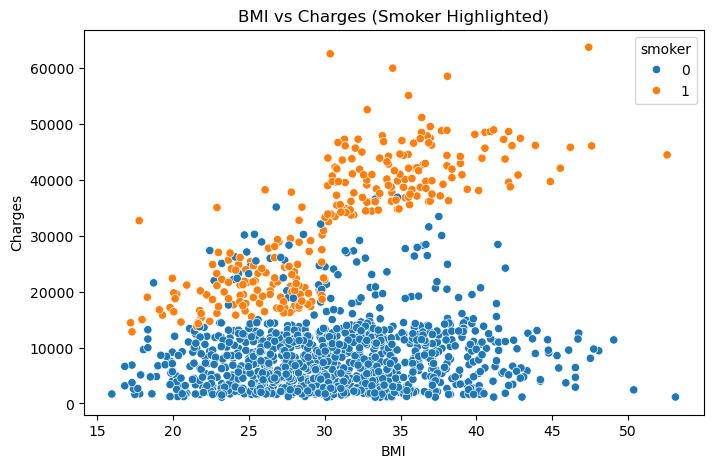

In [8]:
# ================================
# Step 8: Visualizations
# ================================
# BMI (Body Mass Index) is a numerical measure that estimates body fat based on height and weight.
# Formula:
# BMI = weight (kg) ÷ height² (meters)
# 1. BMI vs Charges (highlight smoker effect)
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker')
plt.title("BMI vs Charges (Smoker Highlighted)")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

## Interpretation

- For non-smokers, insurance charges remain mostly low and show little change as BMI increases.
- For smokers, charges are significantly higher at all BMI levels and increase further as BMI rises.
- The highest costs occur in individuals who both smoke and have high BMI.

## Insight

- BMI alone has a limited impact on insurance charges.
- However, when combined with smoking, higher BMI leads to sharply increased costs.
- This shows that smoking amplifies the financial risk associated with high BMI.

# 2. Age vs Charges (highlight smoker effect)
- To examine how age influences insurance charges and to determine whether smoking changes this relationship.

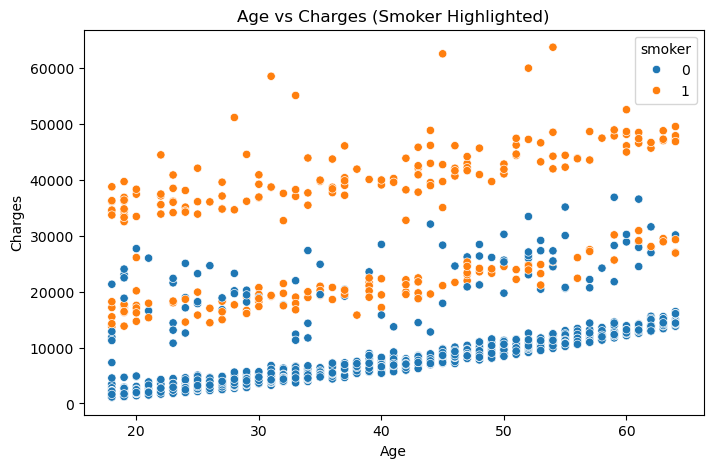

In [9]:
# 2. Age vs Charges (highlight smoker effect)
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='age', y='charges', hue='smoker')
plt.title("Age vs Charges (Smoker Highlighted)")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()


## Interpretation

- Insurance charges increase as age increases for both smokers and non-smokers.
- At every age, smokers have significantly higher charges than non-smokers.
- Older smokers form the highest-cost group.

## Insight

- Age is a strong predictor of insurance charges.
- Smoking shifts insurance costs sharply higher across all age groups.
- The combined effect of aging and smoking leads to the greatest increase in medical expenses.

# 3. Smoker status vs Charges (boxplot)
- To examine how smoking affects insurance charges and determine whether smoking status is a key cost driver.

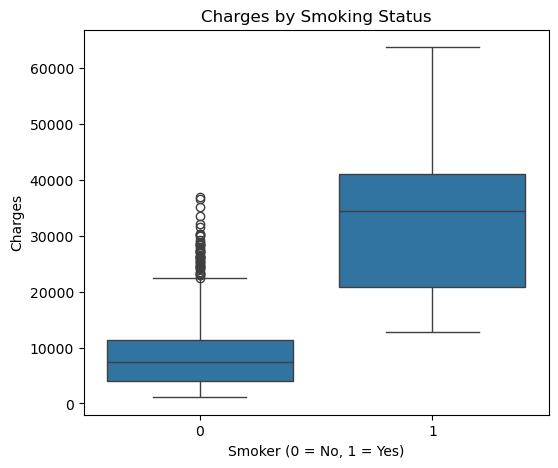

In [10]:
# 3. Smoker status vs Charges (boxplot)
plt.figure(figsize=(6,5))
sns.boxplot(data=df, x='smoker', y='charges')
plt.title("Charges by Smoking Status")
plt.xlabel("Smoker (0 = No, 1 = Yes)")
plt.ylabel("Charges")
plt.show()


## Interpretation

- The boxplot shows a clear separation between smokers and non-smokers.
- Non-smokers have low and tightly grouped insurance charges.
- Smokers have much higher charges with a wide spread of values.
- A few high-cost outliers appear among non-smokers, while high costs are common among smokers.
## Insight

- Smoking status has the strongest impact on insurance charges.
- Smokers consistently incur significantly higher medical costs than non-smokers.
- This indicates that smoking is the primary factor driving insurance expenses in the dataset.

## Overall Conclusion

The analysis shows that smoking status is the most influential factor in determining insurance charges. Smokers consistently incur much higher medical costs than non-smokers. Age is a strong secondary predictor, with charges increasing steadily as individuals grow older. BMI has a weaker overall effect, becoming a significant cost driver mainly among smokers. Together, these patterns explain why individuals who smoke, especially those who are older and have high BMI, represent the highest insurance risk group.